# Fase 5: Explicabilidad del Modelo y Perfiles de Riesgo Geográfico (SHAP)\n
\n
En este notebook abriremos la 'caja negra' del modelo Campeón (LightGBM). Usaremos la librería **SHAP (SHapley Additive exPlanations)**, fundamentada en la teoría de juegos, para extraer matemáticamente cuánto contribuye cada variable al riesgo de desnutrición de un niño.\n
\n
**Objetivos:**\n
1. **Global:** Confirmar visualmente el impacto del Índice de Riqueza, Altitud y variables biológicas.\n
2. **Regional:** Demostrar cómo los factores de riesgo cambian dependiendo de la región geográfica (Costa vs. Sierra vs. Selva), lo cual será la base para la Web App de Streamlit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import shap
import warnings
warnings.filterwarnings('ignore')

# Inicializar visualización de SHAP
shap.initjs()

print("Cargando el Modelo Campeón...")
champion_model = joblib.load('../../models/champion_lightgbm.pkl')

with open('../../models/champion_metadata.json', 'r') as f:
    metadata = json.load(f)

features = metadata['features']
print(f"✅ Modelo cargado. Umbral médico de producción: {metadata['optimal_threshold']:.4f}")

Cargando el Modelo Campeón...
✅ Modelo cargado. Umbral médico de producción: 0.5000


In [2]:
print("Cargando la base de datos...")
df = pd.read_parquet('../../data/processed/master_preprocessed_v2.parquet')

# Recuperar las columnas X usadas por el modelo
import sys
import unicodedata
sys.path.append('../../')
from mnp.configs.column_labels import LABELS

# Identificar variables pasivas a remover
cols_to_drop = [c for c in ['UBIGEO', 'LATITUDY', 'LONGITUDX', 'TARGET_DESNUTRICION', 'year', 'SHREGION', 'HV005', 'hv005', 'HV024'] if c in df.columns]
X = df.drop(columns=cols_to_drop).rename(columns=LABELS)

import re
clean_cols = []
for col in X.columns:
    col_str = unicodedata.normalize('NFKD', str(col)).encode('ASCII', 'ignore').decode('utf-8')
    col_str = re.sub(r'[^a-zA-Z0-9]+', '_', col_str).strip('_')
    clean_cols.append(col_str)
X.columns = clean_cols

    # Restringir X solo a las variables que usa el modelo
X = X[metadata['features']]


# Asegurar formato categórico para LightGBM
for col in metadata['cat_features']:
    X[col] = X[col].astype('category')

print(f"Base de datos cargada: {X.shape}")

Cargando la base de datos...


2026-06-22 03:42:02.833 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


Base de datos cargada: (285284, 43)


In [3]:
# ¡ADVERTENCIA!: Calcular SHAP en 228,000 niños puede demorar HORAS y colapsar la RAM.
# Usaremos una muestra estratificada representativa de 10,000 niños para la explicabilidad.
print("Calculando valores SHAP (Teoría de Juegos) en una muestra representativa...")
X_sample = X.sample(n=10000, random_state=42)

explainer = shap.TreeExplainer(champion_model)
shap_values = explainer(X_sample)
print("[OK] Cálculos SHAP terminados.")

Calculando valores SHAP (Teoría de Juegos) en una muestra representativa...
[OK] Cálculos SHAP terminados.



=== ADN DE LA DESNUTRICIÓN CRÓNICA EN EL PERÚ (Summary Plot) ===
Cómo leer este gráfico:
- Eje Y: Las variables más importantes están arriba.
- Eje X (Hacia la Derecha): Aumenta el RIESGO de Desnutrición.
- Color ROJO: Valor alto de la variable (Ej. Muy rico, Mucha Altitud).
- Color AZUL: Valor bajo de la variable (Ej. Muy pobre, Baja Altitud).


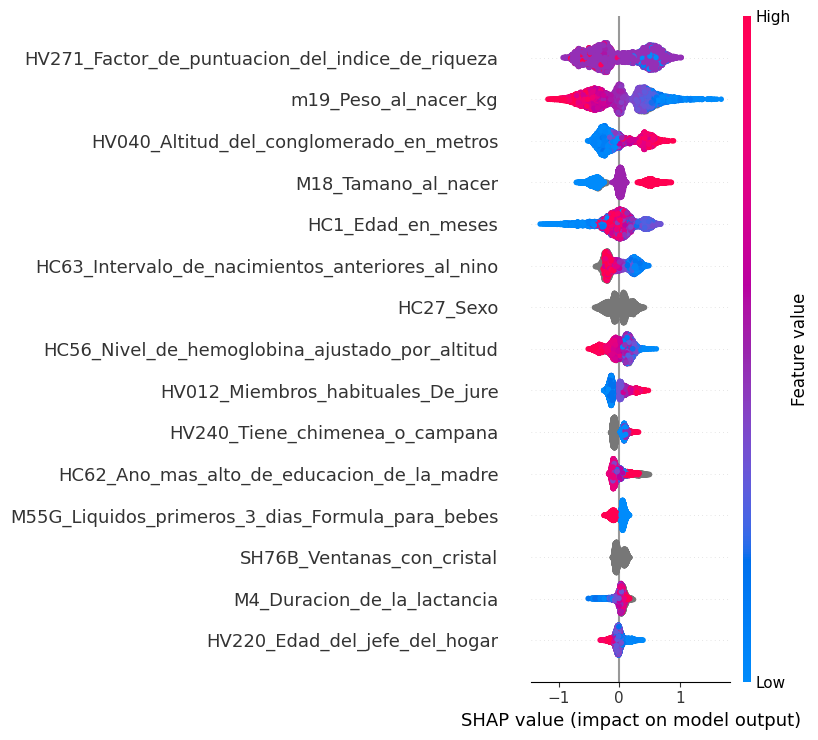

In [4]:
# 1. EL ADN GLOBAL DE LA DESNUTRICIÓN (Summary Plot)
print("\n=== ADN DE LA DESNUTRICIÓN CRÓNICA EN EL PERÚ (Summary Plot) ===")
print("Cómo leer este gráfico:\n" +
      "- Eje Y: Las variables más importantes están arriba.\n" +
      "- Eje X (Hacia la Derecha): Aumenta el RIESGO de Desnutrición.\n" +
      "- Color ROJO: Valor alto de la variable (Ej. Muy rico, Mucha Altitud).\n" +
      "- Color AZUL: Valor bajo de la variable (Ej. Muy pobre, Baja Altitud).")

shap.summary_plot(shap_values, X_sample, max_display=15)


=== CÓMO MUTA LA DESNUTRICIÓN SEGÚN LA REGIÓN (COSTA vs SIERRA vs SELVA) ===


<Figure size 1200x800 with 0 Axes>

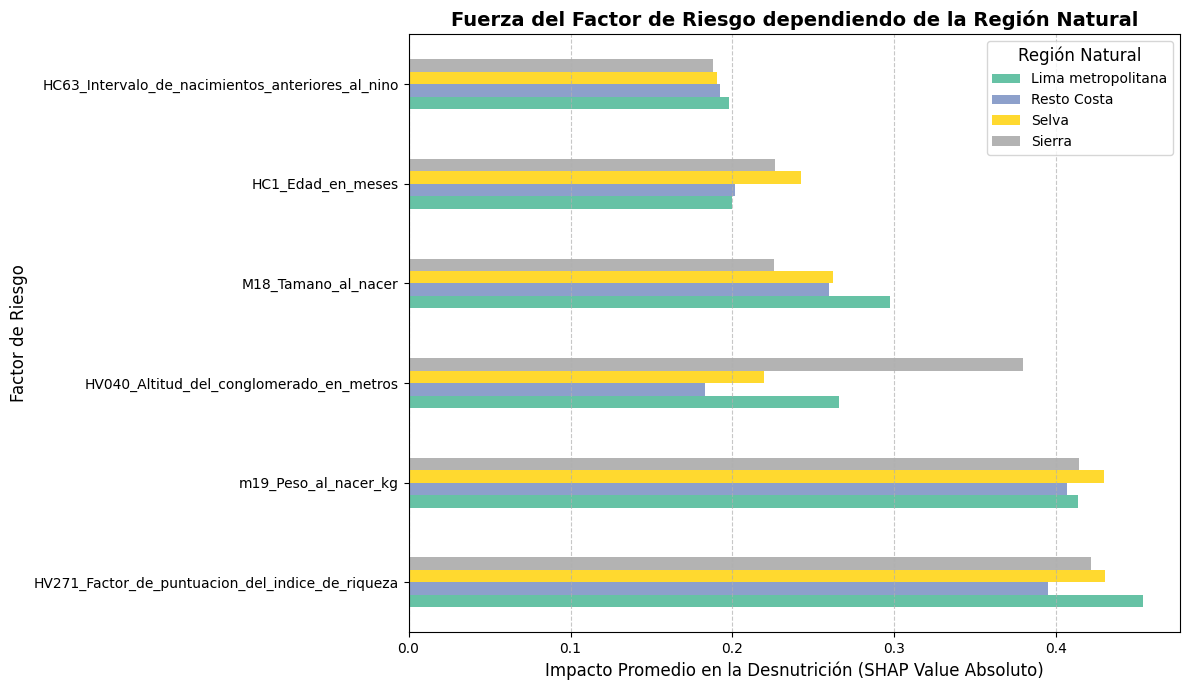

Este gráfico demuestra que la desnutrición no es igual en todo el Perú.
Ejemplo: La Altitud casi no existe como factor de riesgo en la Selva, pero es letal en la Sierra.


In [5]:
# 2. PERFILES DE RIESGO GEOGRÁFICO (El secreto para Streamlit)
print("\n=== CÓMO MUTA LA DESNUTRICIÓN SEGÚN LA REGIÓN (COSTA vs SIERRA vs SELVA) ===")

# Extraemos la columna 'SHREGION' original de los 10,000 niños analizados
region_sample = df.loc[X_sample.index, 'SHREGION']

# Creamos un DataFrame con los valores absolutos de SHAP (que miden la "Fuerza" del impacto)
shap_abs_df = pd.DataFrame(np.abs(shap_values.values), columns=X_sample.columns)
shap_abs_df['REGION'] = region_sample.values

# Agrupamos por Región y calculamos la fuerza promedio de cada variable
regional_impact = shap_abs_df.groupby('REGION').mean(numeric_only=True)

# Calculamos el Top 6 de variables más fuertes a nivel Nacional (según SHAP)
global_importance = shap_abs_df.drop(columns=['REGION']).mean().sort_values(ascending=False)
top_6_vars = global_importance.head(6).index.tolist()

# Filtramos la tabla para mostrar solo esas 6 super-variables
regional_impact_top = regional_impact[top_6_vars]

# Dibujamos el gráfico de barras comparativo
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
regional_impact_top.T.plot(kind='barh', figsize=(12, 7), cmap='Set2')
plt.title('Fuerza del Factor de Riesgo dependiendo de la Región Natural', fontsize=14, fontweight='bold')
plt.xlabel('Impacto Promedio en la Desnutrición (SHAP Value Absoluto)', fontsize=12)
plt.ylabel('Factor de Riesgo', fontsize=12)
plt.legend(title='Región Natural', title_fontsize='12')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Este gráfico demuestra que la desnutrición no es igual en todo el Perú.")
print("Ejemplo: La Altitud casi no existe como factor de riesgo en la Selva, pero es letal en la Sierra.")


=== EL ADN DE LA DESNUTRICIÓN POR DEPARTAMENTO ===


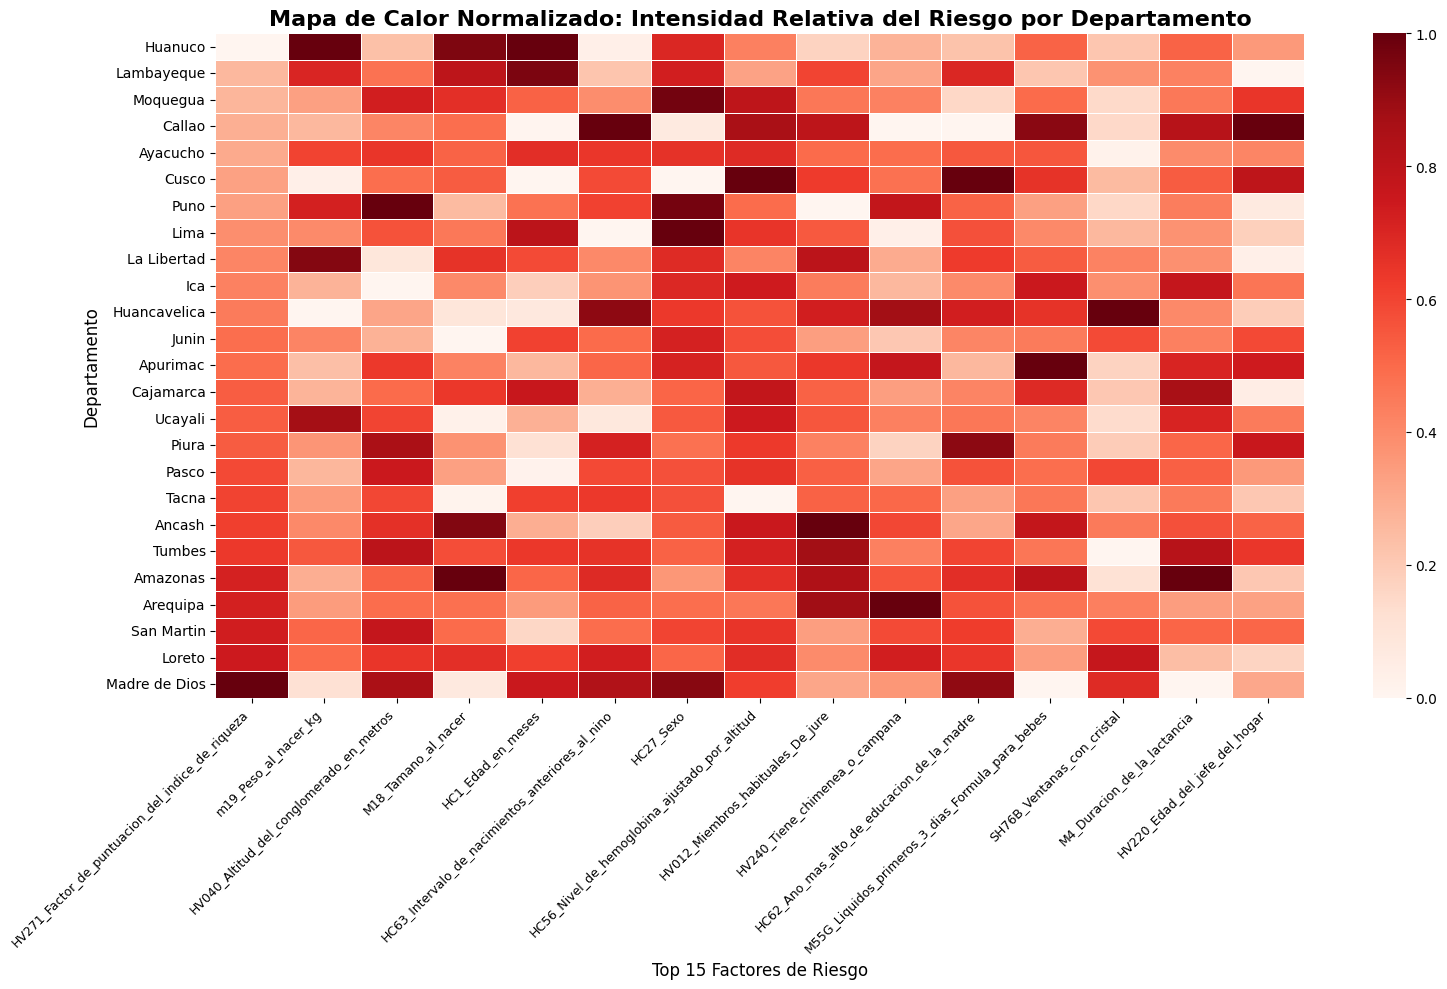

In [6]:
# 3. MAPA DE CALOR POR DEPARTAMENTO (HV024) - VERSIÓN NORMALIZADA
print("\n=== EL ADN DE LA DESNUTRICIÓN POR DEPARTAMENTO ===")

# Rescatamos el departamento de la base de datos original
df_original = pd.read_parquet('../../data/interim/master_merged_v2.parquet', columns=['HV024'])
dept_sample = df_original.loc[X_sample.index, 'HV024']

# Le pegamos el departamento a nuestras Fuerzas de Riesgo (SHAP)
shap_abs_df['DEPARTAMENTO'] = dept_sample.values

# Calculamos el Top 15 de variables más fuertes
top_15_vars = global_importance.head(15).index.tolist()

# Agrupamos por Departamento y promediamos el golpe
dept_impact = shap_abs_df.groupby('DEPARTAMENTO')[top_15_vars].mean()

# TRUCO VISUAL: Normalizamos CADA COLUMNA del 0 al 1.
# Así evitamos que la Riqueza (que tiene números altísimos) "aplaste" y ponga en blanco 
# los colores de la Altitud o la Hemoglobina. 
# Ahora el rojo oscuro significa "Este departamento es el MÁS golpeado por ESTE factor en particular".
dept_impact_norm = (dept_impact - dept_impact.min()) / (dept_impact.max() - dept_impact.min())

# Ordenamos por Riqueza para mantener consistencia
dept_impact_norm = dept_impact_norm.sort_values(by=top_15_vars[0], ascending=True)

# ¡Dibujamos el Mapa de Calor!
plt.figure(figsize=(16, 10))
sns.heatmap(dept_impact_norm, cmap='Reds', linewidths=.5, annot=False)
plt.title('Mapa de Calor Normalizado: Intensidad Relativa del Riesgo por Departamento', fontsize=16, fontweight='bold')
plt.xlabel('Top 15 Factores de Riesgo', fontsize=12)
plt.ylabel('Departamento', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
import os

# ==========================================
# EXPORTACIÓN PARA STREAMLIT (MAPA INTERACTIVO)
# ==========================================
# Calculamos el promedio absoluto de impacto de TODAS las variables por departamento
dept_impact_all = shap_abs_df.groupby('DEPARTAMENTO').mean(numeric_only=True)

os.makedirs('../../data/processed', exist_ok=True)
export_path = '../../data/processed/shap_dept_impact.csv'

# NORMALIZACIÓN MIN-MAX POR COLUMNA (Para que el mapa use la escala 0-1)
dept_impact_norm_all = (dept_impact_all - dept_impact_all.min()) / (dept_impact_all.max() - dept_impact_all.min())
    
dept_impact_norm_all.to_csv(export_path)
print(f"✅ SHAP Geográfico exportado exitosamente a: {export_path}")
print("Streamlit ahora podrá leer este archivo para renderizar los colores del Mapa de Perú.")


✅ SHAP Geográfico exportado exitosamente a: ../../data/processed/shap_dept_impact.csv
Streamlit ahora podrá leer este archivo para renderizar los colores del Mapa de Perú.
